<a href="https://www.kaggle.com/code/sherwinjaysingh/binary-search-tree?scriptVersionId=313533217" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **What is a Binary Tree?**
A binary tree is a hierarchical data structure in which each node has at most two children, referred to as the left child and right child. It's called "binary" because each node can have at most 2 children.

# Visual Example:

```

                    A (Root)
                   /        \
                 B            C
                / \          / \
               D   E        F   G
              /
             H

```
## Terminology:
- **A**: Root (topmost node)
- **B, C**: Children of A (B is left child, C is right child)
- **D, E, F, G**: Internal nodes
- **H, and empty positions**: Leaves or empty children
- **Height**: 3 (A→B→D→H is longest path)
- **Level 0**: A
- **Level 1**: B, C
- **Level 2**: D, E, F, G
- **Level 3**: H
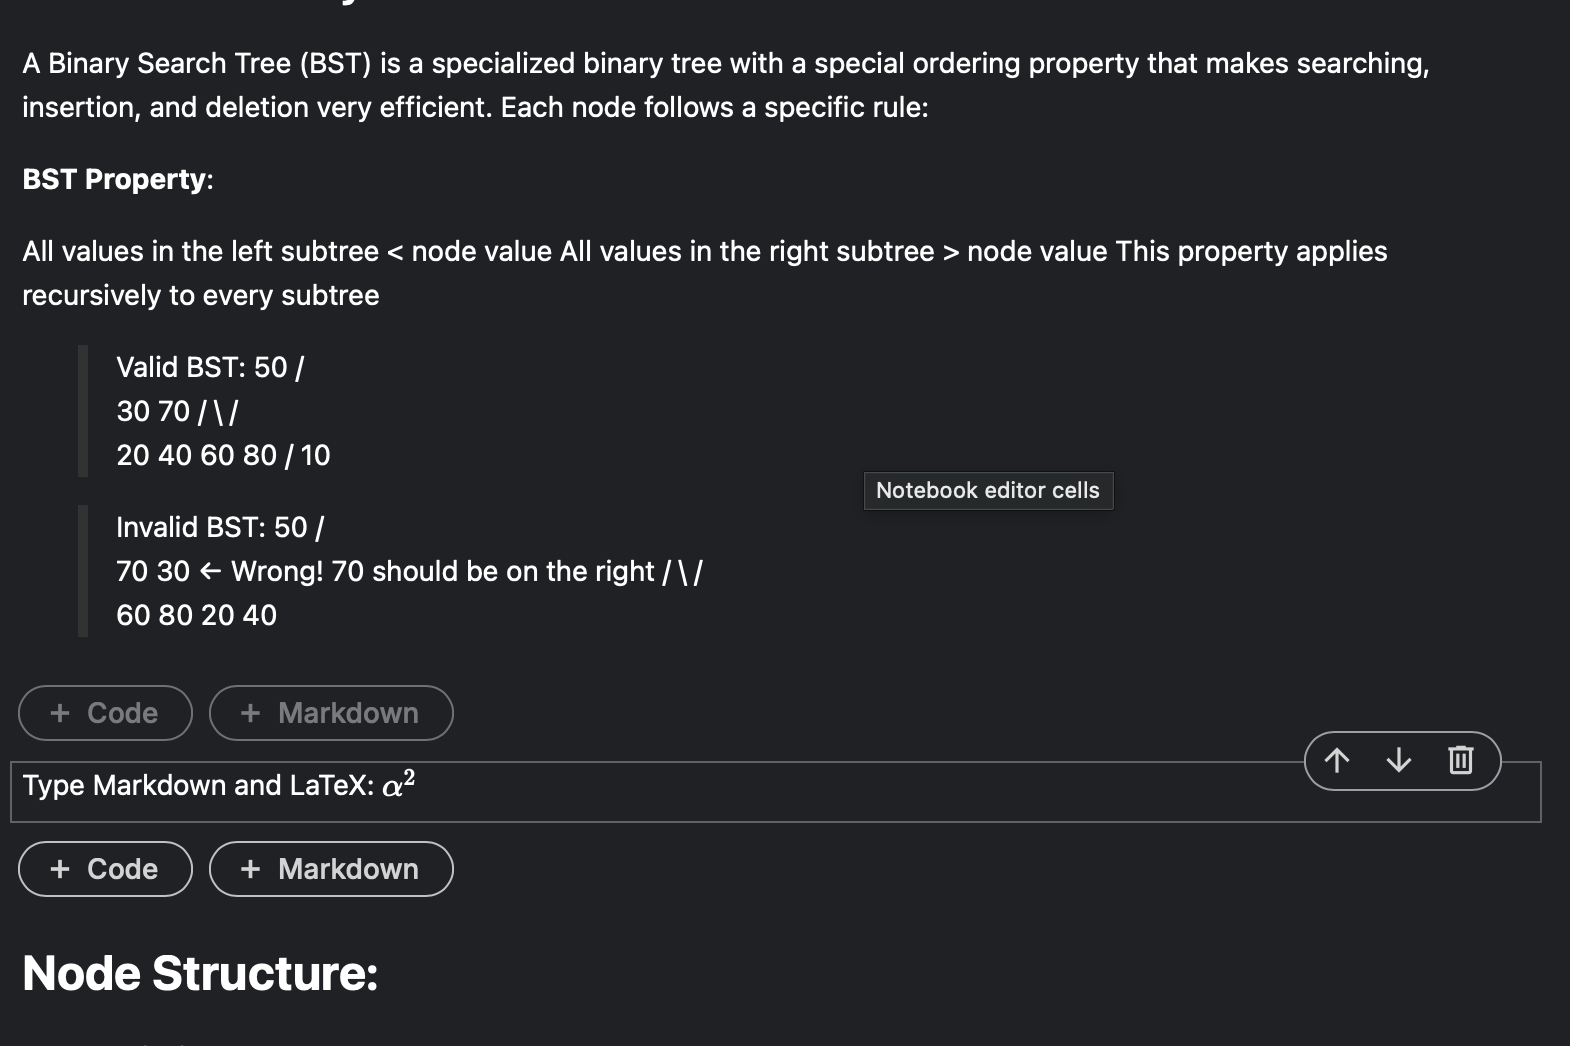

# Key Terminology
* **Root**: The topmost node (has no parent)
* **Parent**: A node that has child nodes
* **Child**: A node connected below another node
* **Leaf**: A node with no children (both left and right are None)
* **Subtree**: A tree formed by any node and its descendants
* **Height**: Length of the longest path from root to leaf
* **Depth**: Length of path from root to a specific node
* **Level**: All nodes at the same depth from root

## **Node Structure:**
- Data/Value
- Pointer to Left Child
- Pointer to Right Child



In [1]:
#This is how you create a class Node to simulate a node in a BST.
class Node:
    def __init__(self, data):
        self.data = data        # Stores the value
        self.left = None        # Points to left child
        self.right = None       # Points to right child

# Types of Binary Trees
* **Full Binary Tree**: Every node has either 0 or 2 children
* **Complete Binary Tree**: All levels filled except possibly the last, filled left to right
* **Perfect Binary Tree**: All internal nodes have 2 children, all leaves at same level
* **Binary Search Tree (BST)**: Left subtree values < node value < right subtree values
* **Balanced Binary Tree**: Height difference between left and right subtrees ≤ 1

*In this notebook, we'll be discussing Binary Search trees*

# Binary Search Tree (BST)
## What is a Binary Search Tree?
A Binary Search Tree (BST) is a specialized binary tree with a special ordering property that makes searching, insertion, and deletion very efficient. Each node follows a specific rule:

**BST Property**:

All values in the left subtree < node value
All values in the right subtree > node value
This property applies recursively to every subtree
```

Valid BST:
        50
       /  \
      30   70
     / \   / \
    20 40 60 80
   /
  10

Invalid BST:
        50
       /  \
      70   30    ← Wrong! 70 should be on the right
     / \   / \
    60 80 20 40


```
### Let's look at another example with a brief explanation:

#### VALID BST: Left < Parent < Right

```

                   50
                 /    \
               30      70
              /  \    /  \
            20   40  60   80
           /
          10

```

**Property Check**:
- 30 < 50 < 70 ✓
- 20, 10 < 30 ✓
- 40 > 30 and 40 < 50 ✓
- 60 > 50 and 60 < 70 ✓
- 80 > 70 ✓

*All subtrees also follow BST property!*

#### INVALID BST: Does NOT follow ordering

```

                   50
                 /    \
               70      30    ← WRONG! 70 should be on right
              /  \    /  \
            60   80  20   40


```
**Problem**:
- 70 > 50, so it should be in right subtree, not left ✗
- This violates the BST property
- Cannot use binary search efficiently

# Core Operations


## Insertion

In [2]:
#Algorithm
#This is just for demonstration; no output expected.

#This is how the insert operation is implemented in python

def _insert_recursive(self, node, data):
    if node is None:                    # Empty spot found
        return Node(data)
    
    if data < node.data:                # Go left
        node.left = self._insert_recursive(node.left, data)
    elif data > node.data:              # Go right
        node.right = self._insert_recursive(node.right, data)
    else:
        print(f"Duplicate not allowed")  # Handle duplicates
    
    return node

**Steps**:
* Start at root
* If value < current node → go left
* If value > current node → go right
* If value == current node → reject duplicate (or update)
* When empty spot found → insert
* Example: Insert 25 into BST with root 50

**Example: Insert 25 into BST with root 50**

Time Complexity: O(log n) average, O(n) worst case (skewed tree)

```

50 > 25? Go left

30 > 25? Go left

20 < 25? Go right

(empty) → Insert 25


```


# Searching

In [3]:
#Algorithm
#This is just for demonstration

#This is how the search operation is implemented in python

def _search_recursive(self, node, data):
    if node is None:
        return False                    # Not found
    if node.data == data:
        return True                     # Found!
    if data < node.data:
        return self._search_recursive(node.left, data)   # Search left
    return self._search_recursive(node.right, data)      # Search right

**Steps**:

* Start at root
* If value == current node → Found!
* If value < current node → search left subtree
* If value > current node → search right subtree
* If reach None → Not found

**Example: Search 40**

* 50: 40 < 50, go left
* 30: 40 > 30, go right
* 40: Found!

**Time Complexity**: O(log n) average, O(n) worst case


**Build a BST and run searches**

```
$ python3 bst_search.py

--- Building BST ---

Inserting: 50 → root

Inserting: 30 → left of 50

Inserting: 70 → right of 50

Inserting: 20 → left of 30

Inserting: 40 → right of 30

Inserting: 60 → left of 70

Inserting: 80 → right of 70

--- Search: 40 ---

Start at root: 50

40 < 50 → go left

Visit node: 30

40 > 30 → go right

Visit node: 40

40 == 40 → Found!

Result: True (3 comparisons, O(log n))

--- Search: 15 ---

Start at root: 50

15 < 50 → go left

Visit node: 30

15 < 30 → go left

Visit node: 20

15 < 20 → go left

Reached None → not found

Result: False (3 comparisons)

--- Search: 60 ---

Start at root: 50

60 > 50 → go right

Visit node: 70

60 < 70 → go left

Visit node: 60

60 == 60 → Found!

Result: True (3 comparisons, O(log n))

```

# Deleting




In [4]:
#Algorithm
#This is just for demonstration; no output expected.

#This is how the delete operation is implemented in python

def _delete_recursive(self, node, data):
        if node is None:
            print(f"Value {data} not found")
            return None
        
        if data < node.data:
            node.left = self._delete_recursive(node.left, data)
        elif data > node.data:
            node.right = self._delete_recursive(node.right, data)
        else:
            # Node found
            print(f"Deleted {data}")
            
            # Case 1: No child or one child
            if node.left is None:
                return node.right
            elif node.right is None:
                return node.left
            
            # Case 2: Two children
            min_node = self.find_min(node.right)
            node.data = min_node.data
            node.right = self._delete_recursive(node.right, min_node.data)
        
        return node

**Here are the three cases for BST deletion:**

Case 1 — Node has no children (leaf): Simply remove it.

Case 2 — Node has one child: Replace the node with its only child.

Case 3 — Node has two children: Find the inorder successor (smallest node in the right subtree), copy its value into the current node, then delete the inorder successor.

In [5]:
from IPython.display import IFrame
IFrame('https://sherwinjaysinghs2025.github.io/bst-visualizer/', width=900, height=600)

# Complete Code (Full Implementation of all required functions)

You should've realized one thing; the search operation and the delete operation doesn't work by itself; it calls other functions to finish its task.

In [6]:
import builtins

# Define the sequence of inputs to "auto-play" your menu
# Example: Insert 50, Insert 30, Search 50, Show Inorder, Exit
demo_sequence = ['1', '50', '1', '30', '3', '50', '4', '12']
mocked_input_stream = iter(demo_sequence)

def input(prompt=""):
    try:
        # Get the next value from our sequence
        response = next(mocked_input_stream)
        print(f"{prompt}{response}") # Print it so the output looks natural
        return response
    except StopIteration:
        return '12' # Safety exit if the sequence runs out

# Override the system input
builtins.input = input

In [7]:
class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None


class BinarySearchTree:
    def __init__(self):
        self.root = None
    
    def insert(self, data):
        self.root = self._insert_recursive(self.root, data)
    
    def _insert_recursive(self, node, data):
        if node is None:
            print(f"Inserted {data}")
            return Node(data)
        
        if data < node.data:
            node.left = self._insert_recursive(node.left, data)
        elif data > node.data:
            node.right = self._insert_recursive(node.right, data)
        else:
            print(f"Duplicate value {data} not inserted")
        
        return node
    
    def search(self, data):
        return self._search_recursive(self.root, data)
    
    def _search_recursive(self, node, data):
        if node is None:
            return False
        if node.data == data:
            return True
        if data < node.data:
            return self._search_recursive(node.left, data)
        return self._search_recursive(node.right, data)
    
    def find_min(self, node=None):
        if node is None:
            node = self.root
        if node is None:
            return None
        while node.left:
            node = node.left
        return node
    
    def find_max(self, node=None):
        if node is None:
            node = self.root
        if node is None:
            return None
        while node.right:
            node = node.right
        return node
    
    def delete(self, data):
        self.root = self._delete_recursive(self.root, data)
    
    def _delete_recursive(self, node, data):
        if node is None:
            print(f"Value {data} not found")
            return None
        
        if data < node.data:
            node.left = self._delete_recursive(node.left, data)
        elif data > node.data:
            node.right = self._delete_recursive(node.right, data)
        else:
            # Node found
            print(f"Deleted {data}")
            
            # Case 1: No child or one child
            if node.left is None:
                return node.right
            elif node.right is None:
                return node.left
            
            # Case 2: Two children
            min_node = self.find_min(node.right)
            node.data = min_node.data
            node.right = self._delete_recursive(node.right, min_node.data)
        
        return node
    
    def inorder_traversal(self, node):
        if node:
            self.inorder_traversal(node.left)
            print(node.data, end=" ")
            self.inorder_traversal(node.right)
    
    def preorder_traversal(self, node):
        if node:
            print(node.data, end=" ")
            self.preorder_traversal(node.left)
            self.preorder_traversal(node.right)
    
    def postorder_traversal(self, node):
        if node:
            self.postorder_traversal(node.left)
            self.postorder_traversal(node.right)
            print(node.data, end=" ")
    
    def count_nodes(self, node):
        if node is None:
            return 0
        return 1 + self.count_nodes(node.left) + self.count_nodes(node.right)
    
    def height(self, node):
        if node is None:
            return 0
        return 1 + max(self.height(node.left), self.height(node.right))
    
    def is_bst(self, node=None, min_val=float('-inf'), max_val=float('inf')):
        if node is None:
            node = self.root
        if node is None:
            return True
        
        if node.data < min_val or node.data > max_val:
            return False
        
        return (self.is_bst(node.left, min_val, node.data - 1) and
                self.is_bst(node.right, node.data + 1, max_val))


if __name__ == "__main__":
    bst = BinarySearchTree()
    
    while True:
        print("\n=== BINARY SEARCH TREE OPERATIONS ===")
        print("1. Insert")
        print("2. Delete")
        print("3. Search")
        print("4. Inorder Traversal (Sorted)")
        print("5. Preorder Traversal")
        print("6. Postorder Traversal")
        print("7. Find Min")
        print("8. Find Max")
        print("9. Count Nodes")
        print("10. Get Height")
        print("11. Check if Valid BST")
        print("12. Exit")
        
        choice = input("\nEnter your choice (1-12): ")
        
        if choice == '1':
            try:
                value = int(input("Enter value to insert: "))
                bst.insert(value)
            except ValueError:
                print("Invalid input! Please enter a number.")
        
        elif choice == '2':
            try:
                value = int(input("Enter value to delete: "))
                bst.delete(value)
            except ValueError:
                print("Invalid input! Please enter a number.")
        
        elif choice == '3':
            try:
                value = int(input("Enter value to search: "))
                print(f"Value {value}: {'Found' if bst.search(value) else 'Not Found'}")
            except ValueError:
                print("Invalid input! Please enter a number.")
        
        elif choice == '4':
            if bst.root is None:
                print("Tree is empty")
            else:
                print("Inorder Traversal (Sorted): ", end="")
                bst.inorder_traversal(bst.root)
                print()
        
        elif choice == '5':
            if bst.root is None:
                print("Tree is empty")
            else:
                print("Preorder Traversal: ", end="")
                bst.preorder_traversal(bst.root)
                print()
        
        elif choice == '6':
            if bst.root is None:
                print("Tree is empty")
            else:
                print("Postorder Traversal: ", end="")
                bst.postorder_traversal(bst.root)
                print()
        
        elif choice == '7':
            min_node = bst.find_min()
            if min_node:
                print(f"Minimum value: {min_node.data}")
            else:
                print("Tree is empty")
        
        elif choice == '8':
            max_node = bst.find_max()
            if max_node:
                print(f"Maximum value: {max_node.data}")
            else:
                print("Tree is empty")
        
        elif choice == '9':
            print(f"Total nodes: {bst.count_nodes(bst.root)}")
        
        elif choice == '10':
            print(f"Height of tree: {bst.height(bst.root)}")
        
        elif choice == '11':
            print(f"Is valid BST: {'Yes' if bst.is_bst() else 'No'}")
        
        elif choice == '12':
            print("Exiting...")
            break
        
        else:
            print("Invalid choice! Please try again.")



=== BINARY SEARCH TREE OPERATIONS ===
1. Insert
2. Delete
3. Search
4. Inorder Traversal (Sorted)
5. Preorder Traversal
6. Postorder Traversal
7. Find Min
8. Find Max
9. Count Nodes
10. Get Height
11. Check if Valid BST
12. Exit

Enter your choice (1-12): 1
Enter value to insert: 50
Inserted 50

=== BINARY SEARCH TREE OPERATIONS ===
1. Insert
2. Delete
3. Search
4. Inorder Traversal (Sorted)
5. Preorder Traversal
6. Postorder Traversal
7. Find Min
8. Find Max
9. Count Nodes
10. Get Height
11. Check if Valid BST
12. Exit

Enter your choice (1-12): 1
Enter value to insert: 30
Inserted 30

=== BINARY SEARCH TREE OPERATIONS ===
1. Insert
2. Delete
3. Search
4. Inorder Traversal (Sorted)
5. Preorder Traversal
6. Postorder Traversal
7. Find Min
8. Find Max
9. Count Nodes
10. Get Height
11. Check if Valid BST
12. Exit

Enter your choice (1-12): 3
Enter value to search: 50
Value 50: Found

=== BINARY SEARCH TREE OPERATIONS ===
1. Insert
2. Delete
3. Search
4. Inorder Traversal (Sorted)
5. Pre

# Advantages of BSTs
* **Efficient search**: O(log n) on average
* **Sorted output**: Inorder gives sorted sequence
* **Dynamic**: Can grow/shrink efficiently
* **Balanced operations**: Better than arrays for frequent insert/delete
* **Recursive structure**: Easy to implement
# Disadvantages of BSTs
* **Worst case degrades**: Unbalanced tree becomes O(n)
* **Complex deletion**: Three cases to handle
* **No random access**: Can't access by index
* **Extra memory**: Pointers for each node
* **Unbalanced by nature**: Sequential inserts can skew tree
# Real-World Applications
* **Database indexing**: SQL databases use B-trees (variant of BST)
* **File systems**: Directory structure
* **Auto-complete**: Search prefix efficiently
* **Expression evaluation**: Parse and evaluate math expressions
* **Range queries**: Find all values in range [a, b]
* **Sorting**: Binary search tree sort
* **Caching**: LRU cache implementations
* **Gaming**: Game tree analysis (minimax)